In [7]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import jit


### Variable

In [8]:
dim = 100
I = 1 # A
hx = 1 # pas spatial
hy = 1 # pas spatial

x = np.linspace(0, dim, dim)
y = np.linspace(0, dim, dim)

xx, yy = np.meshgrid(x, y)

# demi_dist = 5

A = (45, 98)
B = (53, 98)
# M = (48, 98)
# N = (51, 98)

M = (98, 48)
N = (98, 51)


### On met une matrice de conductivité

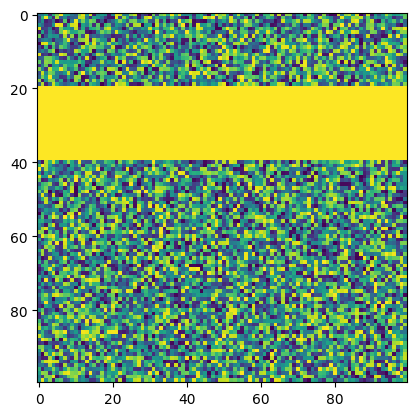

In [9]:
sigma_init = np.random.uniform(low=1, high=10, size=(dim, dim))
sigma_init[20: 40, dim//2 - 50: dim//2 + 50] = 10
pot_init = np.zeros((dim, dim))

courant_init = np.zeros((dim, dim))
courant_init[A[0], A[1]:dim] = I
courant_init[B[0], B[1]:dim] = -I

plt.figure()
plt.imshow(sigma_init)


### Calcul du potentiel

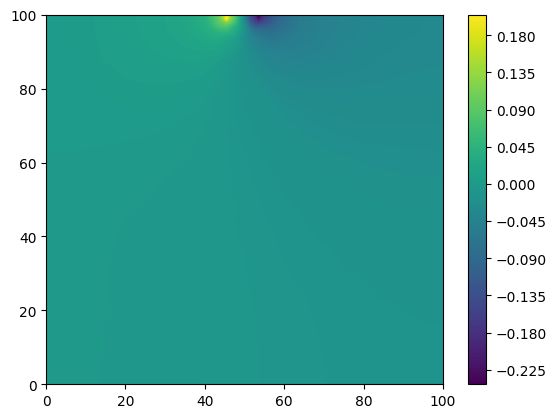

In [ ]:
niter = 1000000
tol = 1e-8
error=1e10
it=0

@numba.jit
def compute_pot(V, V_k, Sigma, I):
    l = len(V[0])
    h = 1
    for i in range(1, l-1):
        for j in range(1, l-1):
            
            sigma_ifhs = (2*Sigma[i, j]*Sigma[i+1, j])/(Sigma[i, j] + Sigma[i+1, j])
            sigma_ibhs = (2*Sigma[i, j]*Sigma[i-1, j])/(Sigma[i, j] + Sigma[i-1, j])
            sigma_jfhs = (2*Sigma[i, j]*Sigma[i, j+1])/(Sigma[i, j] + Sigma[i, j+1])
            sigma_jbhs = (2*Sigma[i, j]*Sigma[i, j-1])/(Sigma[i, j] + Sigma[i, j-1])

            deno = sigma_ifhs + sigma_ibhs + sigma_jfhs + sigma_jbhs

            nom = (I[i, j]*(h**2)) + sigma_ifhs*V_k[i+1, j] + sigma_ibhs*V_k[i-1, j] + sigma_jfhs*V_k[i, j+1] + sigma_jbhs*V_k[i, j-1]

            V[i, j] = nom/deno

    return V

@numba.jit
def find_pot(V, Sigma, I, DIM, error=1e10, tol=1e-8, niter=1000000):
    it=0
    while error > tol and it < niter:
        V_k = V.copy()

        V[0, :] = 0 # haut
        V[-1, :] = V[-2, :] # bas
        V[:, 0] = V[:, 1] # gauche
        V[:, DIM-1] = V[:, DIM-2] # gauche
        #  = 0 # droite

        V = compute_pot(V, V_k, Sigma, I)

        diff = V - V_k
        error = np.sqrt(np.sum(diff**2))#np.linalg.norm(diff)

        it += 1

    return V

Voltage = find_pot(pot_init, sigma_init, courant_init, DIM=dim)

# print(f"Nombre d'itérations: {it}")
# print(f"Erreur: {error}")


plt.figure()
plt.contourf(yy, xx, Voltage, levels=200)
# plt.imshow(pot)
plt.colorbar()
                

### Mesure de la différence de potentiel

In [11]:
def coord_schlumb(A_i, B_i, max_dist):
    A_to_move = A_i[0]
    B_to_move = B_i[0]
    A_list = []
    B_list = []
    for i in range(2, max_dist, 2):
        A = A_to_move - i
        B = B_to_move + i
        A_list.append(A)
        B_list.append(B)

    return list(zip(A_list, B_list))

c = coord_schlumb(A, B, 40)

def pot_for_schlumb(V, M, N):
    dV = V[M] - V[N]
    return dV


def app_res(coord_ab, dimension, cond, I):
    V_i = np.zeros((dimension, dimension))

    rho_app = []
    V_list = []
    AB_2 = []

    for i in coord_ab:
        a, b = i
        AB_2.append((b-a)/2)
        I0 = np.zeros((dimension, dimension))
        V_i = np.zeros((dimension, dimension))
        I0[98, a]=I
        I0[98, b]=-I

        V = find_pot(V_i, cond, I0, DIM=dimension)

        V_list.append(V)

        V_MN = pot_for_schlumb(V, M, N)

        print(M, N)
        print(a, b)

        K = (2 * np.pi) / ((1/abs(a-M[1])) - (1/abs(b-M[1])) - (1/abs(a-N[1])) + (1/abs(b-N[1])))

        rho_ap = K*V_MN/I
        rho_app.append(rho_ap)

    return rho_app, V_list, AB_2

rho_a, V_, ab2 = app_res(c, dim, sigma_init, I)






(98, 48) (98, 51)
43 55
(98, 48) (98, 51)
41 57
(98, 48) (98, 51)
39 59
(98, 48) (98, 51)
37 61
(98, 48) (98, 51)
35 63
(98, 48) (98, 51)
33 65
(98, 48) (98, 51)
31 67
(98, 48) (98, 51)
29 69
(98, 48) (98, 51)
27 71
(98, 48) (98, 51)
25 73
(98, 48) (98, 51)
23 75
(98, 48) (98, 51)
21 77
(98, 48) (98, 51)
19 79
(98, 48) (98, 51)
17 81
(98, 48) (98, 51)
15 83
(98, 48) (98, 51)
13 85
(98, 48) (98, 51)
11 87
(98, 48) (98, 51)
9 89
(98, 48) (98, 51)
7 91


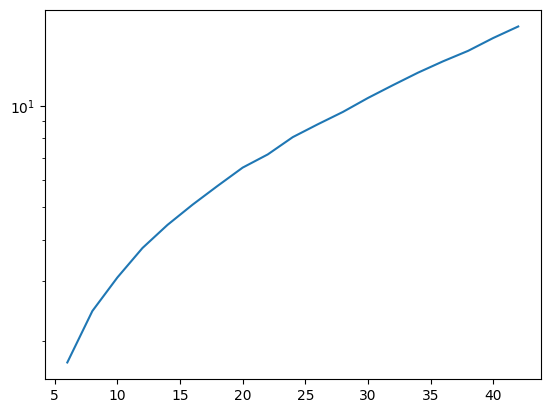

In [12]:
# M = (48, 98)
# N = (51, 98)

# M = (98, 48)
# N = (98, 51)

# V_[0][M] = 0.2
# V_[0][N] = 0.2

plt.figure()
# plt.contourf(xx, yy, V_[0], levels=200)
plt.plot(ab2, rho_a)
plt.yscale('log')

plt.show()